# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
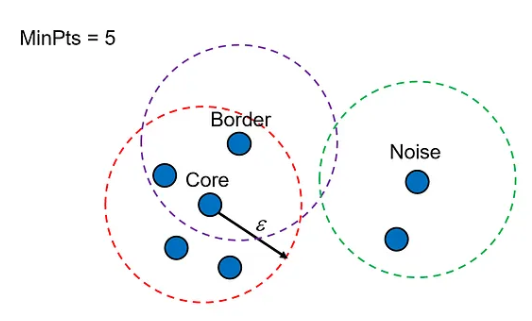

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

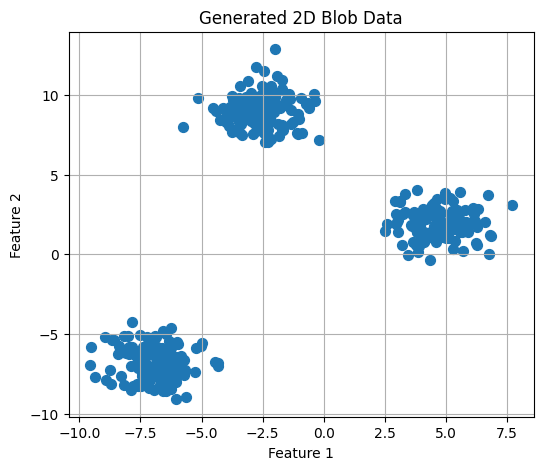

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

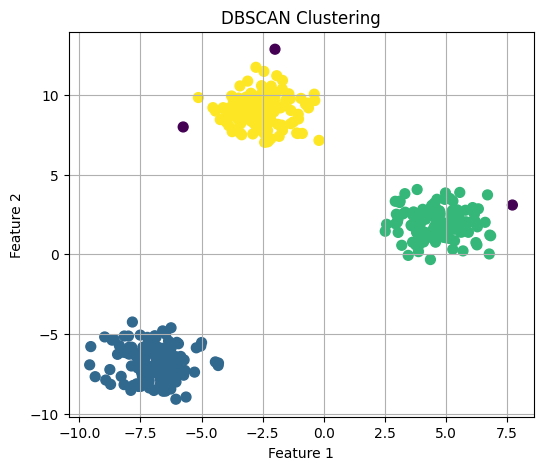

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

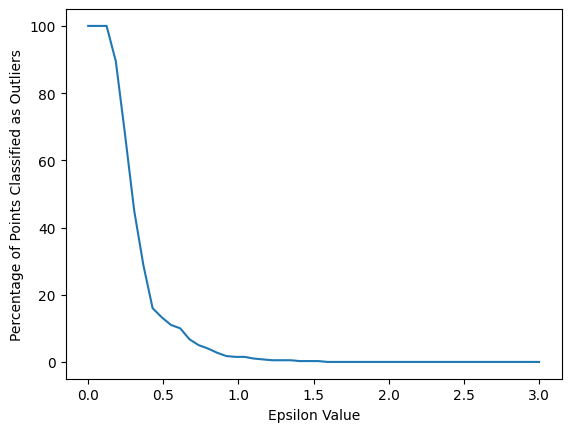

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

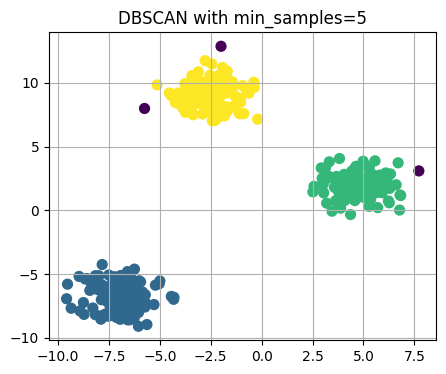

min_samples=5 → Silhouette Score: 0.848


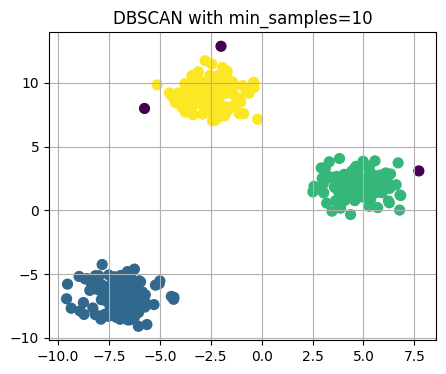

min_samples=10 → Silhouette Score: 0.848


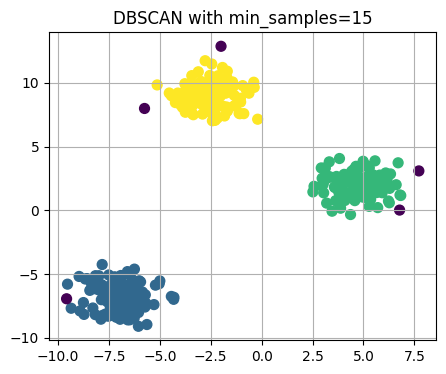

min_samples=15 → Silhouette Score: 0.849


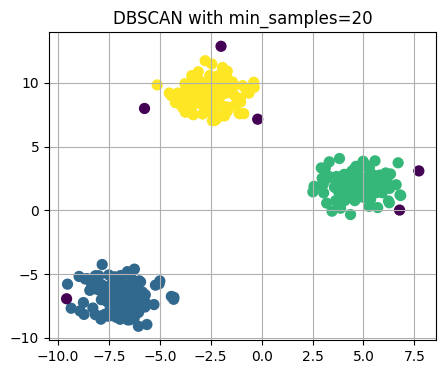

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [117]:
import pandas as pd
import numpy as A
import matplotlib.pyplot as plt

# 1) Load the dataset from CSV into a DataFrame
df = pd.read_csv("CC GENERAL.csv")


In [118]:
# Show basic shape + first rows
print("Shape (rows, cols):", df.shape)


Shape (rows, cols): (8950, 18)


In [119]:
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Credit Card Customer Dataset Description

This dataset contains information about credit card customers.
Each row represents one customer, and the columns describe their
credit usage behavior, purchasing patterns, and repayment activity.

---

## Feature Description

### Categorical Feature
- **CUST_ID** → Unique customer identifier (high cardinality).

---

### Numerical Features (Continuous)

- **BALANCE** → Current balance amount on the credit card.
- **BALANCE_FREQUENCY** → Frequency of balance updates (ratio between 0 and 1).
- **PURCHASES** → Total purchase amount.
- **ONEOFF_PURCHASES** → Amount spent on one-time purchases.
- **INSTALLMENTS_PURCHASES** → Amount spent on installment purchases.
- **CASH_ADVANCE** → Total cash advance amount.
- **PURCHASES_FREQUENCY** → Frequency of purchases (ratio between 0 and 1).
- **ONEOFF_PURCHASES_FREQUENCY** → Frequency of one-time purchases (ratio between 0 and 1).
- **PURCHASES_INSTALLMENTS_FREQUENCY** → Frequency of installment purchases (ratio between 0 and 1).
- **CASH_ADVANCE_FREQUENCY** → Frequency of cash advances (ratio between 0 and 1).
- **CREDIT_LIMIT** → Credit card limit.
- **PAYMENTS** → Total payments made.
- **MINIMUM_PAYMENTS** → Minimum payments made.
- **PRC_FULL_PAYMENT** → Percentage of full payments made (ratio between 0 and 1).

---

### Numerical Features (Discrete)

- **CASH_ADVANCE_TRX** → Number of cash advance transactions.
- **PURCHASES_TRX** → Number of purchase transactions.
- **TENURE** → Number of months the customer has been active.

In [120]:
# 2) Column names + dtypes
print("Columns:")
print(df.columns.tolist())

print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))

Columns:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Dtypes:


,dtype
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [121]:
#select the numeric columns of the data set
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [122]:
#Print (min, max, mean, std, skewness)
numeric_summary = numeric_df.agg(['min', 'max', 'mean', 'std', 'skew']).T
numeric_summary
#skewness scale: =0 for normal distribution, x>(+,-)1 highly skewed 
#positive skewness at x>+1, long right tail 


,min,max,mean,std,skew
BALANCE,0.000000,19043.13856,1564.474828,2081.531879,2.393386
BALANCE_FREQUENCY,0.000000,1.00000,0.877271,0.236904,-2.023266
PURCHASES,0.000000,49039.57000,1003.204834,2136.634782,8.144269
ONEOFF_PURCHASES,0.000000,40761.25000,592.437371,1659.887917,10.045083
INSTALLMENTS_PURCHASES,0.000000,22500.00000,411.067645,904.338115,7.299120
CASH_ADVANCE,0.000000,47137.21176,978.871112,2097.163877,5.166609
PURCHASES_FREQUENCY,0.000000,1.00000,0.490351,0.401371,0.060164
ONEOFF_PURCHASES_FREQUENCY,0.000000,1.00000,0.202458,0.298336,1.535613
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000,1.00000,0.364437,0.397448,0.509201
CASH_ADVANCE_FREQUENCY,0.000000,1.50000,0.135144,0.200121,1.828686


In [123]:
categorical_df = df.select_dtypes(include=["object"])
categorical_df.columns

Index(['CUST_ID'], dtype='object')

In [124]:
for col in categorical_df.columns:
    print(f"\n===== {col} =====")
    print(df[col])


===== CUST_ID =====
0       C10001
1       C10002
2       C10003
3       C10004
4       C10005
         ...  
8945    C19186
8946    C19187
8947    C19188
8948    C19189
8949    C19190
Name: CUST_ID, Length: 8950, dtype: object


In [125]:
df.isnull().sum()



CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

,missing_count,missing_pct
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


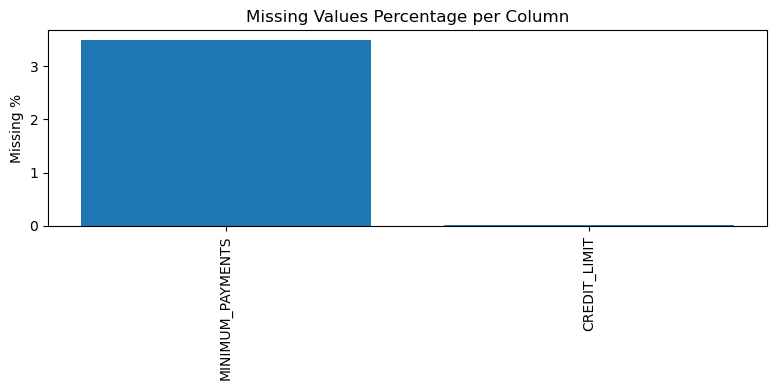

In [126]:
# Missing values count + percentage
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

# Show only columns with missing
missing_table = missing_table[missing_table["missing_count"] > 0]
display(missing_table)

# Plot missing % (if any)
if len(missing_table) > 0:
    plt.figure(figsize=(8,4))
    plt.bar(missing_table.index, missing_table["missing_pct"])
    plt.xticks(rotation=90)
    plt.ylabel("Missing %")
    plt.title("Missing Values Percentage per Column")
    plt.tight_layout()
    plt.show()

since the data missing is less than 5% it is safe to either impute with median or drop missing
I will:
-drop the one customer with the missing credit limit
-impute the minimum payments with median

In [127]:
#investigating correlations
corr_matrix = numeric_df.corr()
corr_matrix


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303985,0.453238,0.140107,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119788,0.103464,0.003030,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295038,0.243537,-0.030327,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060755,0.085551,0.030073,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132616,0.183192,0.098838,-0.249773,-0.133372


In [128]:
#check for high correlated columns for |corr|>0.7
import numpy as np

threshold = 0.7
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):   # avoid duplicates and self-correlation
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 round(corr_value, 3))
            )

high_corr_pairs

[('ONEOFF_PURCHASES', 'PURCHASES', 0.917),
 ('PURCHASES_INSTALLMENTS_FREQUENCY', 'PURCHASES_FREQUENCY', 0.863),
 ('CASH_ADVANCE_TRX', 'CASH_ADVANCE_FREQUENCY', 0.8)]

In [129]:
#detect outliers:
numeric_df = df.select_dtypes(include=["int64", "float64"])

outlier_counts = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = numeric_df[(numeric_df[col] < lower_bound) | 
                          (numeric_df[col] > upper_bound)]
    
    outlier_counts[col] = len(outliers)

outlier_counts

{'BALANCE': 695,
 'BALANCE_FREQUENCY': 1493,
 'PURCHASES': 808,
 'ONEOFF_PURCHASES': 1013,
 'INSTALLMENTS_PURCHASES': 867,
 'CASH_ADVANCE': 1030,
 'PURCHASES_FREQUENCY': 0,
 'ONEOFF_PURCHASES_FREQUENCY': 782,
 'PURCHASES_INSTALLMENTS_FREQUENCY': 0,
 'CASH_ADVANCE_FREQUENCY': 525,
 'CASH_ADVANCE_TRX': 804,
 'PURCHASES_TRX': 766,
 'CREDIT_LIMIT': 248,
 'PAYMENTS': 808,
 'MINIMUM_PAYMENTS': 841,
 'PRC_FULL_PAYMENT': 1474,
 'TENURE': 1366}

In [130]:
#outliers percentages
outlier_percentage = {
    col: (count / len(df)) * 100
    for col, count in outlier_counts.items()
}

outlier_percentage

{'BALANCE': 7.76536312849162,
 'BALANCE_FREQUENCY': 16.68156424581006,
 'PURCHASES': 9.027932960893855,
 'ONEOFF_PURCHASES': 11.318435754189943,
 'INSTALLMENTS_PURCHASES': 9.687150837988828,
 'CASH_ADVANCE': 11.508379888268157,
 'PURCHASES_FREQUENCY': 0.0,
 'ONEOFF_PURCHASES_FREQUENCY': 8.737430167597765,
 'PURCHASES_INSTALLMENTS_FREQUENCY': 0.0,
 'CASH_ADVANCE_FREQUENCY': 5.865921787709497,
 'CASH_ADVANCE_TRX': 8.983240223463687,
 'PURCHASES_TRX': 8.558659217877095,
 'CREDIT_LIMIT': 2.7709497206703912,
 'PAYMENTS': 9.027932960893855,
 'MINIMUM_PAYMENTS': 9.396648044692737,
 'PRC_FULL_PAYMENT': 16.46927374301676,
 'TENURE': 15.262569832402233}

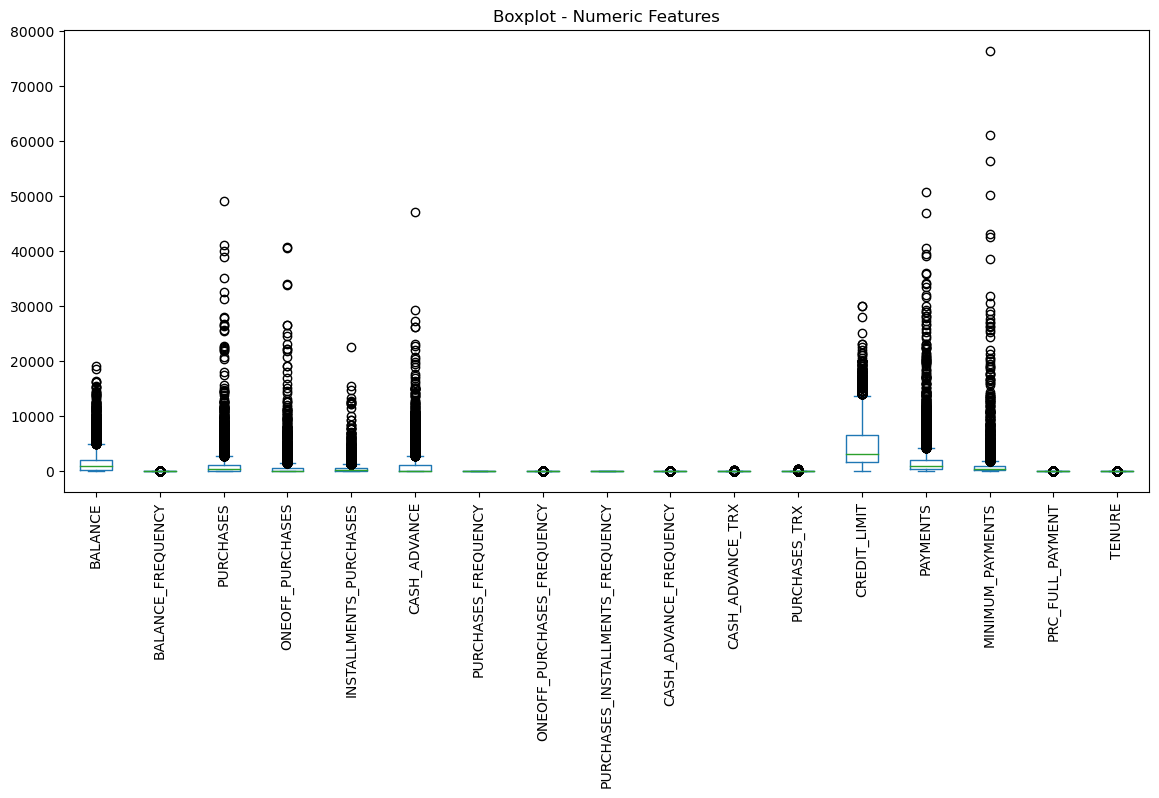

In [131]:
#boxplot for outliers
import matplotlib.pyplot as plt

numeric_df.plot(kind="box", figsize=(14,6), rot=90)
plt.title("Boxplot - Numeric Features")
plt.show()

## 2. Data Preparation

In [132]:
# Drop rows where CREDIT_LIMIT is missing
df = df.dropna(subset=["CREDIT_LIMIT"])

print("Shape after dropping missing CREDIT_LIMIT:", df.shape)

Shape after dropping missing CREDIT_LIMIT: (8949, 18)


In [133]:
# Compute median before imputation (for reporting)
median_min_payment = df["MINIMUM_PAYMENTS"].median()
print("Median MINIMUM_PAYMENTS:", median_min_payment)

# Fill missing values with median
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(median_min_payment)

Median MINIMUM_PAYMENTS: 312.4522915


In [134]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

since high correlation between the next pairs: 
Keep PURCHASES, remove ONEOFF_PURCHASES

Keep PURCHASES_FREQUENCY, remove PURCHASES_INSTALLMENTS_FREQUENCY

Keep CASH_ADVANCE_FREQUENCY, remove CASH_ADVANCE_TRX

In [135]:
df = df.drop(columns=[
    "ONEOFF_PURCHASES",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_TRX"
])


In [136]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

CUST_ID completely should be removed before clustering since CUST_ID is:

A unique identifier

High cardinality (8950 unique values)

Has no behavioral meaning

Artificial label

In [137]:
df = df.drop(columns=["CUST_ID"])
numeric_df = df.select_dtypes(include=["int64", "float64"])
df.dtypes

BALANCE                       float64
BALANCE_FREQUENCY             float64
PURCHASES                     float64
INSTALLMENTS_PURCHASES        float64
CASH_ADVANCE                  float64
PURCHASES_FREQUENCY           float64
ONEOFF_PURCHASES_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY        float64
PURCHASES_TRX                   int64
CREDIT_LIMIT                  float64
PAYMENTS                      float64
MINIMUM_PAYMENTS              float64
PRC_FULL_PAYMENT              float64
TENURE                          int64
dtype: object

In [138]:
df.isnull().sum().sum()

0

Because:

Data is skewed

Outliers exist

Financial distributions are long-tailed

Scale using:

StandardScaler (Z-score normalization)

In [139]:
df.isnull().sum().sum()

0

In [140]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## 3. Apply DBSCAN




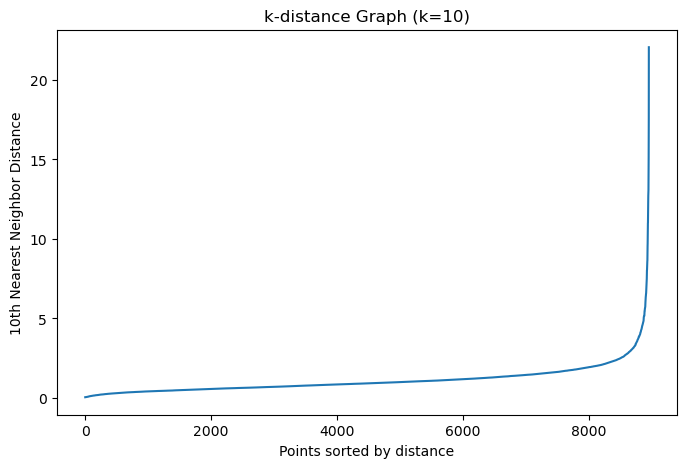

In [162]:
#if a dense region has at least 5 points
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)

# Sort distances of the 5th neighbor (take the distance to the fifth nearest neighbor for each point)
distances = np.sort(distances[:,9])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("k-distance Graph (k=10)")
plt.xlabel("Points sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
for min_samples in [5,10,15,20,25]:
    for eps in [0.5, 1, 1.5, 2.0, 2.5, 3.0, 3.5]:
        model = DBSCAN(eps=eps, min_samples= min_samples)
        labels = model.fit_predict(scaled_data)
    
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
    
        print(f"min_samples={min_samples} | eps={eps} | clusters={n_clusters} | noise%={round(noise/len(labels)*100,2)}")

min_samples=5 | eps=0.5 | clusters=29 | noise%=68.57
min_samples=5 | eps=1 | clusters=7 | noise%=26.92
min_samples=5 | eps=1.5 | clusters=3 | noise%=9.9
min_samples=5 | eps=2.0 | clusters=2 | noise%=4.5
min_samples=5 | eps=2.5 | clusters=3 | noise%=2.55
min_samples=5 | eps=3.0 | clusters=1 | noise%=1.54
min_samples=5 | eps=3.5 | clusters=1 | noise%=1.14
min_samples=10 | eps=0.5 | clusters=11 | noise%=75.92
min_samples=10 | eps=1 | clusters=3 | noise%=32.37
min_samples=10 | eps=1.5 | clusters=1 | noise%=12.45
min_samples=10 | eps=2.0 | clusters=1 | noise%=5.25
min_samples=10 | eps=2.5 | clusters=1 | noise%=2.98
min_samples=10 | eps=3.0 | clusters=1 | noise%=1.87
min_samples=10 | eps=3.5 | clusters=1 | noise%=1.33
min_samples=15 | eps=0.5 | clusters=3 | noise%=79.61
min_samples=15 | eps=1 | clusters=2 | noise%=35.99
min_samples=15 | eps=1.5 | clusters=1 | noise%=14.63
min_samples=15 | eps=2.0 | clusters=1 | noise%=5.97
min_samples=15 | eps=2.5 | clusters=1 | noise%=3.21
min_samples=15 | 

In [166]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

eps = 1.0
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
db_labels = dbscan.fit_predict(scaled_data)

df["DBSCAN_Cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

print("DBSCAN parameters: eps =", eps, ", min_samples =", min_samples)
print("Number of clusters found:", n_clusters)
print("Number of noise points (-1):", n_noise)
print("Noise %:", round(n_noise / len(db_labels) * 100, 2))

DBSCAN parameters: eps = 1.0 , min_samples = 10
Number of clusters found: 3
Number of noise points (-1): 2897
Noise %: 32.37


In [167]:
#cluster sizes including noise
cluster_counts = pd.Series(db_labels).value_counts().sort_index()
display(cluster_counts.to_frame("count"))

,count
-1,2897
0,6032
1,8
2,12


## 4. Evaluate the Clustering

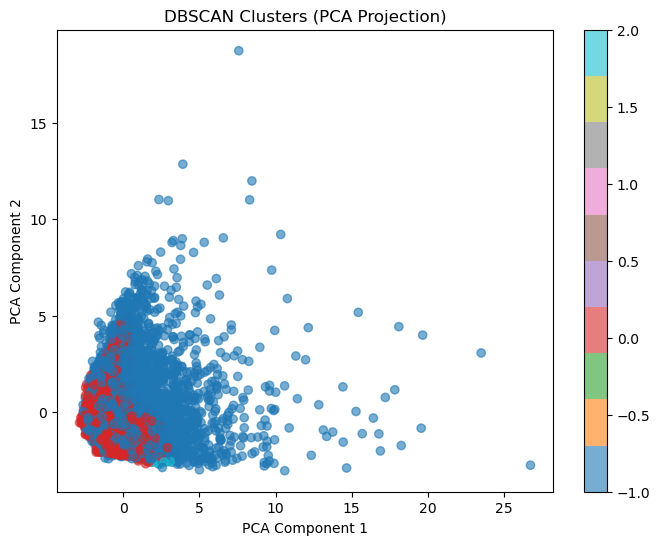

In [168]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=db_labels, cmap="tab10", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clusters (PCA Projection)")
plt.colorbar(sc)
plt.show()

In [169]:
clustered_only = df[df["DBSCAN_Cluster"] != -1]
cluster_profile = clustered_only.groupby("DBSCAN_Cluster").mean(numeric_only=True)
display(cluster_profile)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
DBSCAN_Cluster,,,,,,,,,,,,,,
0,1051.199728,0.868626,451.795502,218.448097,501.752664,0.424599,0.131018,0.099003,8.236572,3330.499047,852.118230,479.660204,0.134359,11.684184
1,285.489052,1.000000,2583.016250,1024.002500,124.908793,0.968750,0.614583,0.020833,32.375000,5875.000000,2217.122757,191.797218,0.366288,12.000000
2,231.845125,1.000000,2640.200000,519.635000,0.000000,0.993056,0.986111,0.000000,51.916667,3091.666667,2475.075199,173.423268,0.928662,12.000000


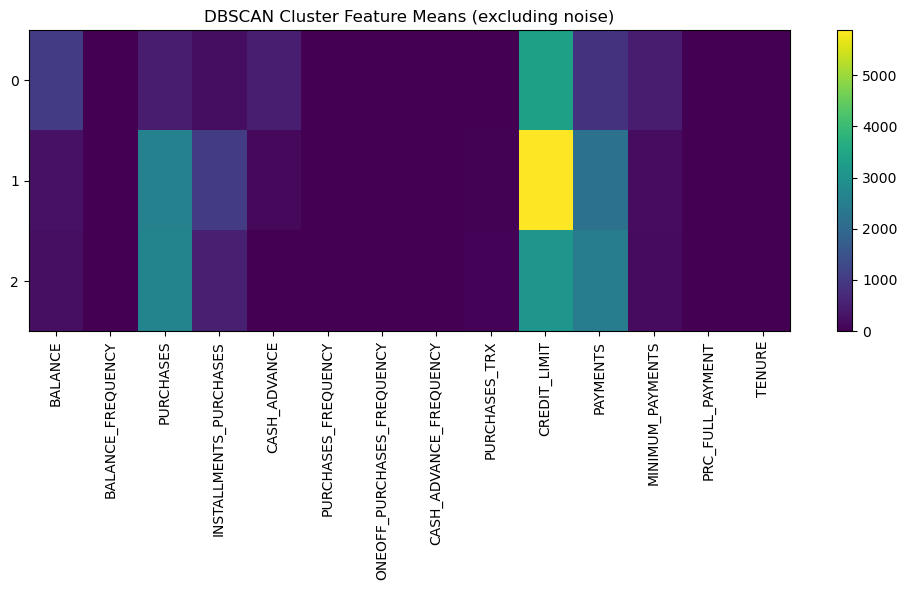

In [170]:
#heat map
plt.figure(figsize=(10,6))
plt.imshow(cluster_profile.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(cluster_profile.columns)), cluster_profile.columns, rotation=90)
plt.yticks(range(len(cluster_profile.index)), cluster_profile.index)
plt.title("DBSCAN Cluster Feature Means (excluding noise)")
plt.tight_layout()
plt.show()

In [171]:
from sklearn.metrics import silhouette_score

mask = db_labels != -1  # exclude noise
unique_clusters = set(db_labels[mask])

if len(unique_clusters) >= 2:
    sil = silhouette_score(scaled_data[mask], db_labels[mask])
    print("Silhouette Score (excluding noise):", round(sil, 3))
else:
    print("Silhouette score not reliable (need >= 2 clusters excluding noise).")

Silhouette Score (excluding noise): 0.11


## DBSCAN Clustering Evaluation



DBSCAN was applied using eps = 1.0 and min_samples = 10

The algorithm identified 3 clusters and labeled approximately 32% of the data points as noise. This indicates that a significant portion of customers do not belong to dense regions and exhibit irregular or sparse behavior patterns.

The PCA visualization shows partial separation between clusters, but noticeable overlap remains. This suggests that the dataset does not contain strongly density-separated groups. Instead, customer financial behavior appears to form a continuous spectrum rather than clearly defined dense regions.

DBSCAN revealed limited natural density structure. Increasing eps resulted in collapse into a single large cluster, while decreasing eps produced excessive fragmentation and noise.

Overall, DBSCAN provided meaningful insight by identifying core dense customer groups and distinguishing irregular customers as noise. However, the relatively high noise percentage and moderate cluster separation indicate that density-based clustering is less suitable for this dataset compared to hierarchical clustering.